## Step 1: Import thư viện

Bước này import các thư viện cần thiết để thực hiện Market Basket Analysis bằng Python.

Các thư viện chính gồm:

- `apriori`: tìm frequent itemsets bằng thuật toán Apriori.
- `fpgrowth`: tìm frequent itemsets bằng thuật toán FP-Growth.
- `association_rules`: tạo luật kết hợp từ frequent itemsets.
- `time`: đo thời gian chạy của từng thuật toán.

In [2]:
import pandas as pd
import numpy as np
import time

from mlxtend.frequent_patterns import apriori, fpgrowth
from mlxtend.frequent_patterns import association_rules

import matplotlib.pyplot as plt

## Step 2: Tải ma trận giao dịch

Bước này tải ma trận giao dịch đã được tạo ở giai đoạn preprocessing.

Trong ma trận giao dịch:

- Mỗi dòng đại diện cho một basket.
- Mỗi cột đại diện cho một sản phẩm.
- Giá trị `1` hoặc `True` nghĩa là sản phẩm xuất hiện trong basket.
- Giá trị `0` hoặc `False` nghĩa là sản phẩm không xuất hiện trong basket.

Ma trận này là đầu vào cho cả Apriori và FP-Growth.

In [3]:
transaction_matrix_path = "online_retail_ii_transaction_matrix.csv"

transaction_matrix = pd.read_csv(
    transaction_matrix_path,
    index_col=0
)

print("Shape:", transaction_matrix.shape)

transaction_matrix.head()

Shape: (35945, 4809)


,10002R,10080,10109,10120,10123C,10123G,10124A,10124G,10125,10133,...,DCGS0058,DCGS0062,DCGS0066N,DCGS0069,DCGS0070,DCGS0076,DCGSSBOY,DCGSSGIRL,PADS,SP1002
10002,,,,,,,,,,,,,,,,,,,,,
False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
True,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 3: Chạy thuật toán Apriori

Bước này sử dụng thuật toán Apriori để tìm các frequent itemsets trong ma trận giao dịch.

Ngưỡng `min_support = 0.01` được sử dụng để giữ lại các tập sản phẩm xuất hiện trong ít nhất 1% tổng số basket.

In [4]:
min_support_value = 0.01

start_time = time.time()

frequent_itemsets_apriori = apriori(
    transaction_matrix,
    min_support=min_support_value,
    use_colnames=True
)

apriori_time = time.time() - start_time

print("Number of frequent itemsets from Apriori:", len(frequent_itemsets_apriori))
print("Apriori running time:", round(apriori_time, 4), "seconds")

frequent_itemsets_apriori.head()

Number of frequent itemsets from Apriori: 1187
Apriori running time: 97.1327 seconds


,support,itemsets
0,0.021922,(15036)
1,0.022674,(15056BL)
2,0.026624,(15056N)
3,0.010071,(15060B)
4,0.011406,(16156S)


## Step 4: Chạy thuật toán FP-Growth

Bước này sử dụng thuật toán FP-Growth để tìm các frequent itemsets với cùng ngưỡng `min_support`.

FP-Growth thường chạy nhanh hơn Apriori vì không cần sinh nhiều candidate itemsets.

In [5]:
start_time = time.time()

frequent_itemsets_fpgrowth = fpgrowth(
    transaction_matrix,
    min_support=min_support_value,
    use_colnames=True
)

fpgrowth_time = time.time() - start_time

print("Number of frequent itemsets from FP-Growth:", len(frequent_itemsets_fpgrowth))
print("FP-Growth running time:", round(fpgrowth_time, 4), "seconds")

frequent_itemsets_fpgrowth.head()

Number of frequent itemsets from FP-Growth: 1187
FP-Growth running time: 6.2213 seconds


,support,itemsets
0,0.060871,(21232)
1,0.028432,(21523)
2,0.018167,(21871)
3,0.015579,(22064)
4,0.013548,(22041)


## Step 5: So sánh Apriori và FP-Growth

Bước này so sánh hai thuật toán theo:

- Số lượng frequent itemsets tìm được
- Thời gian chạy

Nếu dùng cùng `min_support`, hai thuật toán thường cho số lượng frequent itemsets giống nhau, nhưng FP-Growth thường chạy nhanh hơn Apriori.

In [6]:
comparison_df = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Number of Frequent Itemsets": [
        len(frequent_itemsets_apriori),
        len(frequent_itemsets_fpgrowth)
    ],
    "Running Time (seconds)": [
        round(apriori_time, 4),
        round(fpgrowth_time, 4)
    ]
})

comparison_df

,Algorithm,Number of Frequent Itemsets,Running Time (seconds)
0,Apriori,1187,97.1327
1,FP-Growth,1187,6.2213


## Step 6: Sinh Association Rules

Sau khi tìm được frequent itemsets, bước này tạo các luật kết hợp bằng hàm `association_rules`.

Ở bước này, ta sử dụng frequent itemsets từ FP-Growth vì thuật toán này cho kết quả giống Apriori nhưng chạy nhanh hơn nhiều.

Các luật được tạo dựa trên ngưỡng confidence tối thiểu.

In [7]:
min_confidence_value = 0.2

rules = association_rules(
    frequent_itemsets_fpgrowth,
    metric="confidence",
    min_threshold=min_confidence_value
)

print("Number of association rules:", len(rules))

rules.head()

Number of association rules: 1173


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(21232),(21212),0.060871,0.079594,0.012630,0.207495,2.606929,1.0,0.007785,1.161389,0.656360,0.098803,0.138962,0.183091
1,(21232),(85123A),0.060871,0.141299,0.016164,0.265539,1.879270,1.0,0.007563,1.169158,0.498204,0.086898,0.144684,0.189966
2,(84879),(85123A),0.075643,0.141299,0.019196,0.253770,1.795974,1.0,0.008508,1.150718,0.479468,0.097074,0.130978,0.194812
3,(21754),(85123A),0.053777,0.141299,0.018083,0.336265,2.379807,1.0,0.010485,1.293740,0.612749,0.102169,0.227047,0.232121
4,(21181),(85123A),0.046682,0.141299,0.013048,0.279499,1.978068,1.0,0.006452,1.191811,0.518669,0.074587,0.160941,0.185920


## Step 7: Lọc các Association Rules có ý nghĩa

Sau khi sinh association rules, số lượng luật ban đầu còn khá lớn. Vì vậy, bước này lọc các luật theo các tiêu chí chặt hơn để giữ lại những luật có giá trị phân tích tốt hơn.

Các tiêu chí lọc gồm:

- `support >= 0.01`: luật xuất hiện trong ít nhất 1% tổng số basket.
- `confidence >= 0.3`: khi khách mua sản phẩm vế trái, xác suất mua sản phẩm vế phải phải đạt ít nhất 30%.
- `lift > 1`: hai sản phẩm có xu hướng được mua cùng nhau cao hơn mức ngẫu nhiên.

Các luật sau khi lọc sẽ được sử dụng để phân tích cross-selling.

In [8]:
filtered_rules = rules[
    (rules["support"] >= 0.01) &
    (rules["confidence"] >= 0.3) &
    (rules["lift"] > 1)
].copy()

print("Number of filtered rules:", len(filtered_rules))

filtered_rules.head()

Number of filtered rules: 837


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(21754),(85123A),0.053777,0.141299,0.018083,0.336265,2.379807,1.0,0.010485,1.293740,0.612749,0.102169,0.227047,0.232121
5,(21754),(21755),0.053777,0.044318,0.022562,0.419555,9.466986,1.0,0.020179,1.646465,0.945199,0.298711,0.392638,0.464329
6,(21755),(21754),0.044318,0.053777,0.022562,0.509102,9.466986,1.0,0.020179,1.927537,0.935844,0.298711,0.481203,0.464329
7,(21755),(85123A),0.044318,0.141299,0.016664,0.376020,2.661162,1.0,0.010402,1.376167,0.653171,0.098633,0.273344,0.246978
8,(22111),(22112),0.043594,0.044179,0.015218,0.349075,7.901441,1.0,0.013292,1.468404,0.913254,0.209739,0.318989,0.346767


## Step 8: Lọc các luật mạnh hơn

Sau bước lọc cơ bản, số lượng rules vẫn còn khá lớn. Vì vậy, bước này tiếp tục áp dụng điều kiện chặt hơn để chọn các luật có giá trị phân tích tốt hơn.

Các điều kiện lọc gồm:

- `support >= 0.01`
- `confidence >= 0.4`
- `lift >= 2`

Các luật sau bước này sẽ được dùng cho top rules, network graph và mô phỏng add-to-cart lift.

In [9]:
strong_rules = rules[
    (rules["support"] >= 0.01) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 2)
].copy()

print("Number of strong rules:", len(strong_rules))

strong_rules.head()

Number of strong rules: 614


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(21754),(21755),0.053777,0.044318,0.022562,0.419555,9.466986,1.0,0.020179,1.646465,0.945199,0.298711,0.392638,0.464329
6,(21755),(21754),0.044318,0.053777,0.022562,0.509102,9.466986,1.0,0.020179,1.927537,0.935844,0.298711,0.481203,0.464329
11,(20972),(20971),0.035081,0.028544,0.016024,0.456780,16.002894,1.0,0.015023,1.788331,0.971596,0.336645,0.440819,0.509092
12,(20971),(20972),0.028544,0.035081,0.016024,0.561404,16.002894,1.0,0.015023,2.200014,0.965058,0.336645,0.545458,0.509092
13,(22273),(22271),0.020587,0.019864,0.010099,0.490541,24.695350,1.0,0.009690,1.923875,0.979675,0.332722,0.480216,0.499472


## Step 9: Chọn Top 20 Association Rules

Do association rules có thể xuất hiện theo hai chiều như `A → B` và `B → A`, việc chỉ lấy Top 10 có thể làm kết quả thiếu đa dạng.

Vì vậy, bước này chọn Top 20 rules theo các tiêu chí:

- `lift`
- `confidence`
- `support`

Top 20 rules sẽ được dùng cho phân tích, trực quan hóa và mô phỏng add-to-cart lift.

In [10]:
top_rules = (
    strong_rules
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .head(20)
    .copy()
)

top_rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
1146,"(22748, 22745)",(22746),0.010433,0.741107,52.646405
1147,(22746),"(22748, 22745)",0.010433,0.741107,52.646405
1144,"(22746, 22748)",(22745),0.010433,0.870070,50.606233
1149,(22745),"(22746, 22748)",0.010433,0.606796,50.606233
422,(22300),(22301),0.010015,0.762712,48.782345
423,(22301),(22300),0.010015,0.640569,48.782345
1145,"(22746, 22745)",(22748),0.010433,0.899281,48.681687
1148,(22748),"(22746, 22745)",0.010433,0.564759,48.681687
1142,(22746),(22745),0.011601,0.824111,47.933104
1143,(22745),(22746),0.011601,0.674757,47.933104


## Step 10: Chuyển Association Rules sang dạng dễ đọc

Các cột `antecedents` và `consequents` đang ở dạng tập sản phẩm.

Bước này chuyển chúng thành chuỗi văn bản để dễ đọc, dễ trực quan hóa và dễ đưa vào báo cáo.

Cột mới `rule` sẽ có dạng:

`antecedents → consequents`

In [11]:
def itemset_to_string(itemset):
    # Chuyển tập sản phẩm thành chuỗi
    return ", ".join([str(item) for item in itemset])

# Chuyển antecedents và consequents sang dạng chuỗi
top_rules["antecedents_str"] = top_rules["antecedents"].apply(itemset_to_string)
top_rules["consequents_str"] = top_rules["consequents"].apply(itemset_to_string)

# Tạo cột rule để hiển thị luật kết hợp
top_rules["rule"] = (
    top_rules["antecedents_str"] +
    " → " +
    top_rules["consequents_str"]
)

# Hiển thị kết quả
top_rules[[
    "rule",
    "support",
    "confidence",
    "lift"
]]

,rule,support,confidence,lift
1146,"22748, 22745 → 22746",0.010433,0.741107,52.646405
1147,"22746 → 22748, 22745",0.010433,0.741107,52.646405
1144,"22746, 22748 → 22745",0.010433,0.870070,50.606233
1149,"22745 → 22746, 22748",0.010433,0.606796,50.606233
422,22300 → 22301,0.010015,0.762712,48.782345
423,22301 → 22300,0.010015,0.640569,48.782345
1145,"22746, 22745 → 22748",0.010433,0.899281,48.681687
1148,"22748 → 22746, 22745",0.010433,0.564759,48.681687
1142,22746 → 22745,0.011601,0.824111,47.933104
1143,22745 → 22746,0.011601,0.674757,47.933104


## Step 11: Trực quan hóa Top 20 Association Rules theo Lift

Bước này trực quan hóa 20 luật kết hợp có giá trị `lift` cao nhất.

`Lift` càng cao cho thấy mối quan hệ giữa sản phẩm vế trái và sản phẩm vế phải càng mạnh.

Biểu đồ này giúp xác định các luật có tiềm năng cross-selling tốt nhất.

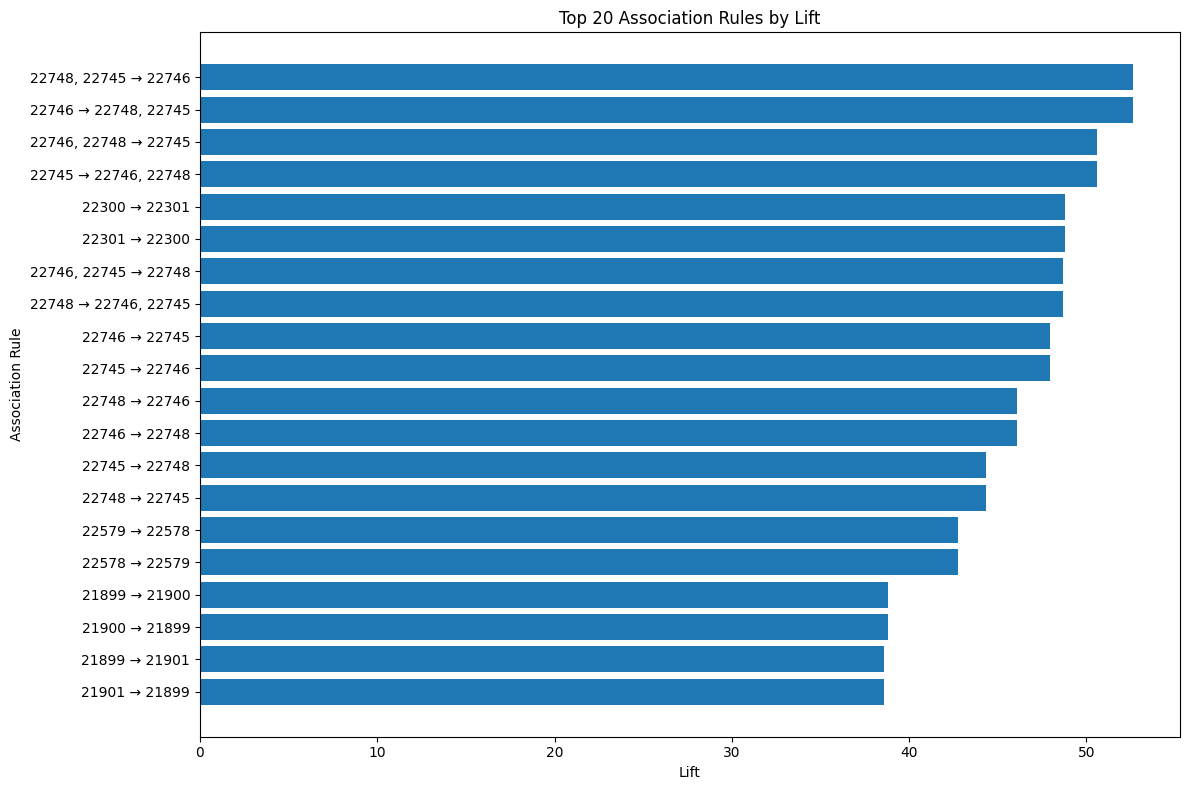

In [12]:
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ top 20 rules theo lift
plt.barh(
    top_rules["rule"],
    top_rules["lift"]
)

plt.title("Top 20 Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Step 12: Mô phỏng Add-to-Cart Lift cho Top 20 Rules

Bước này mô phỏng tác động tiềm năng nếu áp dụng các association rules để gợi ý sản phẩm.

Nếu một luật có dạng `A → B` và `confidence = 0.7`, điều đó nghĩa là trong số các basket có sản phẩm A, khoảng 70% cũng có sản phẩm B.

Với giả định có 1,000 khách hàng mua sản phẩm vế trái, ta ước lượng số lượt mua thêm sản phẩm vế phải tiềm năng.

In [13]:
assumed_customers = 1000

simulation_df = top_rules[[
    "rule",
    "confidence",
    "lift"
]].copy()

# Ước lượng số lượt add-to-cart tiềm năng
simulation_df["assumed_customers"] = assumed_customers
simulation_df["estimated_add_to_cart"] = (
    simulation_df["confidence"] * assumed_customers
).round(0).astype(int)

simulation_df

,rule,confidence,lift,assumed_customers,estimated_add_to_cart
1146,"22748, 22745 → 22746",0.741107,52.646405,1000,741
1147,"22746 → 22748, 22745",0.741107,52.646405,1000,741
1144,"22746, 22748 → 22745",0.870070,50.606233,1000,870
1149,"22745 → 22746, 22748",0.606796,50.606233,1000,607
422,22300 → 22301,0.762712,48.782345,1000,763
423,22301 → 22300,0.640569,48.782345,1000,641
1145,"22746, 22745 → 22748",0.899281,48.681687,1000,899
1148,"22748 → 22746, 22745",0.564759,48.681687,1000,565
1142,22746 → 22745,0.824111,47.933104,1000,824
1143,22745 → 22746,0.674757,47.933104,1000,675


## Trực quan hóa kết quả mô phỏng Add-to-Cart Lift

Bước này trực quan hóa số lượt add-to-cart tiềm năng của Top 20 association rules.

Biểu đồ giúp xác định rule nào có khả năng tạo ra nhiều lượt mua thêm nhất khi được áp dụng vào hệ thống gợi ý

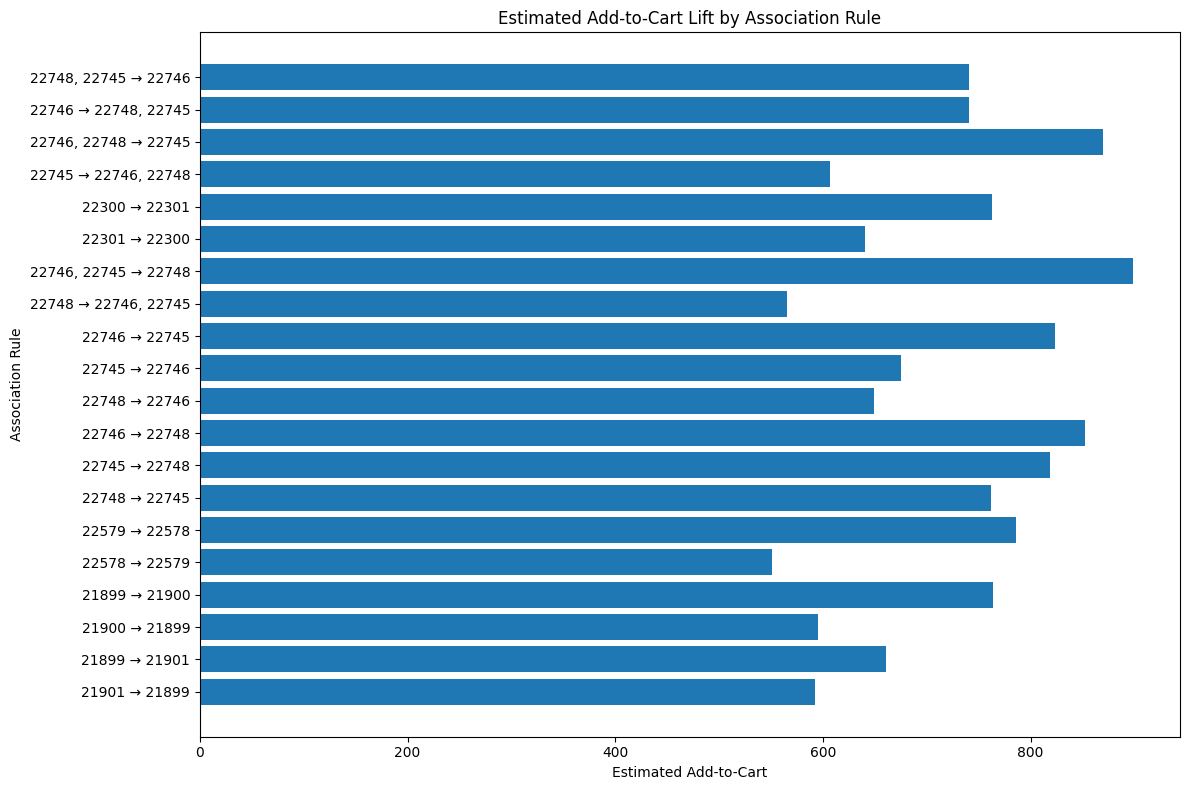

In [14]:
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ số lượt add-to-cart ước lượng theo từng rule
plt.barh(
    simulation_df["rule"],
    simulation_df["estimated_add_to_cart"]
)

plt.title("Estimated Add-to-Cart Lift by Association Rule")
plt.xlabel("Estimated Add-to-Cart")
plt.ylabel("Association Rule")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## Step 13: Lưu các kết quả quan trọng

Bước này chỉ lưu các kết quả cần thiết nhất cho báo cáo và phân tích tiếp theo.

Các file được lưu gồm:

- `association_rules_strong.csv`: các luật mạnh sau khi lọc.
- `top_20_association_rules.csv`: 20 luật tốt nhất để đưa vào báo cáo.
- `add_to_cart_lift_simulation.csv`: kết quả mô phỏng add-to-cart lift.

In [ ]:
# Lưu các luật mạnh sau khi lọc
strong_rules.to_csv(
    "association_rules_strong.csv",
    index=False
)

# Lưu top 20 association rules
top_rules.to_csv(
    "top_20_association_rules.csv",
    index=False
)

# Lưu kết quả mô phỏng add-to-cart lift
simulation_df.to_csv(
    "add_to_cart_lift_simulation.csv",
    index=False
)

print("Important outputs saved successfully.")

Important outputs saved successfully.
